1. Load and merge

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Notebook is in src/, so ../results/figures points to project_root/results/figures
fig_dir = Path("../results/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

base = pd.read_csv("../data/features.csv")
base.columns

meta = pd.read_csv("../data/new_metadata.csv")

# Merge on img_id
df = base.merge(meta, on="img_id")

# Create binary label
cancerous = ["BCC", "MEL", "SCC"]
df["label"] = df["diagnostic"].isin(cancerous).astype(int)

2. Basic Statistics

In [2]:
print(df["diameter"].describe())

count    1945.000000
mean        0.967731
std         0.057477
min         0.311268
25%         0.960274
50%         0.991573
75%         1.000000
max         1.000000
Name: diameter, dtype: float64


3. Distribution plot

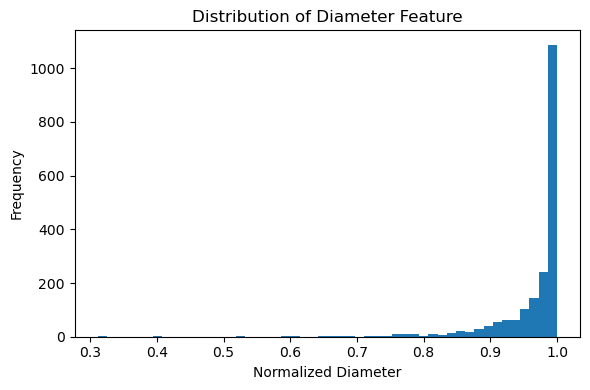

In [3]:
plt.figure(figsize=(6,4))
plt.hist(df["diameter"], bins=50)
plt.xlabel("Normalized Diameter")
plt.ylabel("Frequency")
plt.title("Distribution of Diameter Feature")
plt.tight_layout()
plt.savefig(fig_dir / "diameter_distribution.png", dpi=300)
plt.show()


4. Benign vs malignant comparison

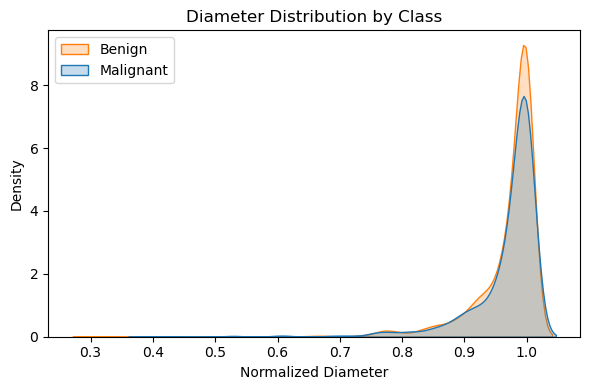

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="diameter", hue="label", fill=True)

plt.legend(["Benign", "Malignant"])
plt.xlabel("Normalized Diameter")
plt.ylabel("Density")
plt.title("Diameter Distribution by Class")

plt.tight_layout()
plt.savefig(fig_dir / "diameter_by_class.png", dpi=300)
plt.show()

5. Boxplot

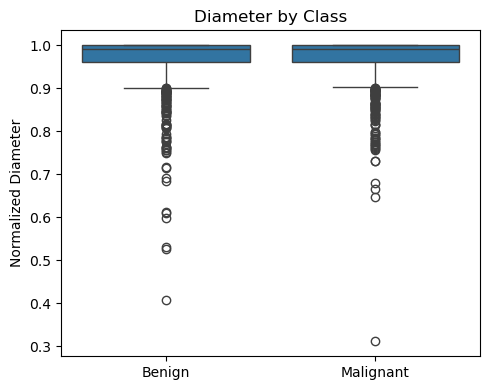

In [5]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="label", y="diameter")

plt.xticks([0,1], ["Benign", "Malignant"])
plt.xlabel("")
plt.ylabel("Normalized Diameter")
plt.title("Diameter by Class")

plt.tight_layout()
plt.savefig(fig_dir / "diameter_boxplot.png", dpi=300)
plt.show()


6. Statistical test

In [6]:
from scipy.stats import mannwhitneyu

benign = df[df["label"] == 0]["diameter"]
malignant = df[df["label"] == 1]["diameter"]

stat, p = mannwhitneyu(benign, malignant)

print(f"p-value: {p}")

p-value: 0.9056695061184916


7. Correlation check

In [7]:
df[["diameter", "label"]].corr()

,diameter,label
diameter,1.000000,0.018537
label,0.018537,1.000000
